Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exploring Customers dataset

In [38]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [39]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [40]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

In [41]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [42]:
customers.value_counts("customer_city")

customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64

In [43]:
customers.value_counts("customer_state")

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [44]:
customers.value_counts("customer_unique_id")

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [45]:
customers.value_counts("customer_id")

customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
18955e83d337fd6b2def6b18a428ac77    1
4e7b3e00288586ebd08712fdd0374a03    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
                                   ..
17ddf5dd5d51696bb3d7c6291687be6f    1
e7b71a9017aa05c9a7fd292d714858e8    1
5e28dfe12db7fb50a4b2f691faecea5e    1
56b18e2166679b8a959d72dd06da27f9    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64

This table contains 5 columns, including customer identifiers, zip code, city, and state, with 99441 records and no missing values.

The states with the highest number of customers are SP, RJ, MG, RS, and PR. Similarly, São Paulo, Rio de Janeiro, Belo Horizonte, Brasília and Curitiba are the cities with the most customers.

Regarding customer identification, the column `customer_id` is unique for each order, meaning that a new customer record is created for every purchase. In contrast, `customer_unique_id` represents the actual customer, as it can appear multiple times across different orders.

This distinction allows for the analysis of customer behavior over time, such as identifying repeat customers and measuring retention.


## Exploring Orders dataset

In [46]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [47]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [48]:
orders.value_counts("order_status")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [49]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders["order_purchase_timestamp"])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders['order_approved_at'] = pd.to_datetime(orders["order_approved_at"])
orders['order_delivered_customer_date'] = pd.to_datetime(orders["order_delivered_customer_date"])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders["order_estimated_delivery_date"])

### Average delivery time

In [68]:
orders["delivery_time"] = orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
avg_delivery_time = orders["delivery_time"].mean()
avg_delivery_time

Timedelta('12 days 13:24:31.879068')

In [ ]:
orders.dtypes

order_id                                     str
customer_id                                  str
order_status                                 str
order_purchase_timestamp          datetime64[us]
order_approved_at                 datetime64[us]
order_delivered_carrier_date      datetime64[us]
order_delivered_customer_date     datetime64[us]
order_estimated_delivery_date     datetime64[us]
delivery_time                    timedelta64[us]
dtype: object

### Was the delivery made on time?

In [77]:
# 1 = TRUE / 0 = FALSE
orders["is_on_time"] = np.where(
    orders["order_delivered_customer_date"].notna(),
    orders["order_delivered_customer_date"] <= orders["order_estimated_delivery_date"],
    np.nan
)

delivered_orders = orders[orders["is_on_time"].notna()]

perc_delivered_on_time = delivered_orders["is_on_time"].mean()
print(f"On time deliveries = {perc_delivered_on_time*100:.2f}%")

perc_not_delivered_on_time = 1 - perc_delivered_on_time
print(f"Late deliveries = {perc_not_delivered_on_time*100:.2f}%")

On time deliveries = 91.89%
Late deliveries = 8.11%


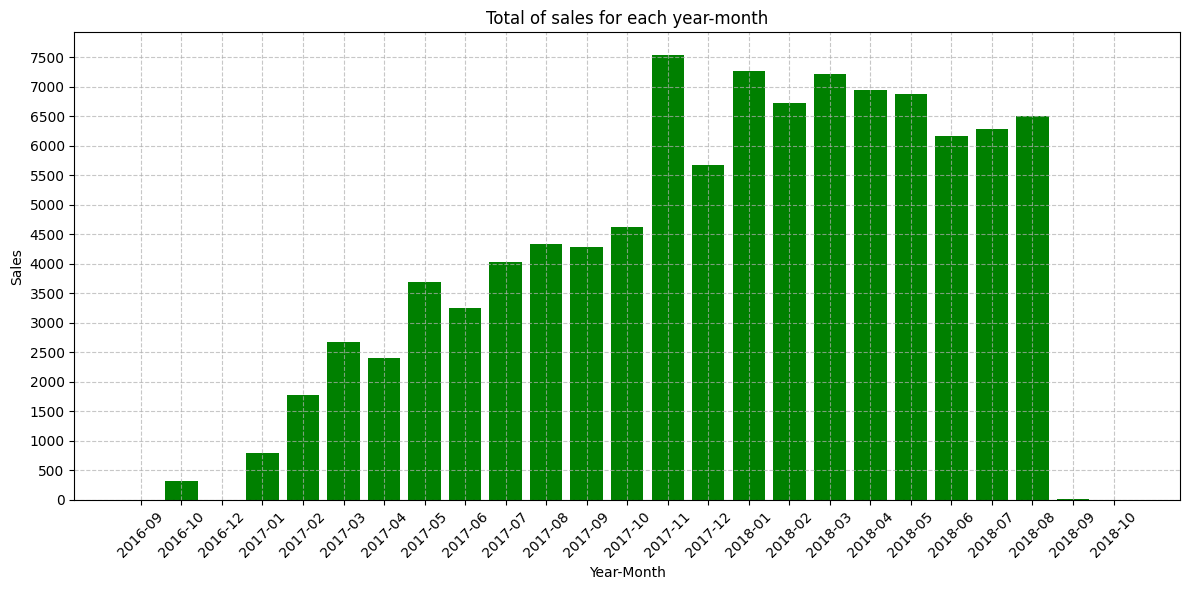

In [ ]:
#orders
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
sales_per_month = orders.groupby('year_month')['order_id'].count().reset_index()
sales_per_month


orders_date = sales_per_month['year_month'].astype(str)
sales = sales_per_month['order_id']

plt.figure(figsize=(12, 6))
plt.bar(orders_date, sales, color='green')
plt.xlabel('Year-Month')
plt.ylabel('Sales')
plt.title('Total of Sales for each Year-Month')
plt.xticks(rotation=45)
max_sales = sales.max() + 200
plt.yticks(range(0, max_sales, 500))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()



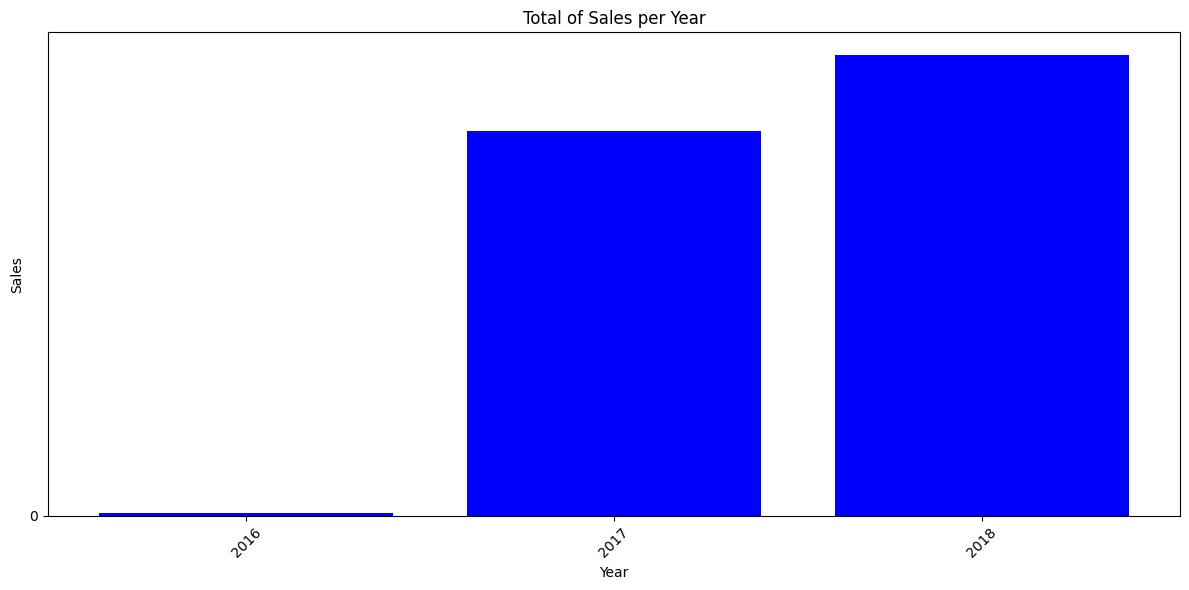

In [ ]:
#orders
orders['year'] = orders['order_purchase_timestamp'].dt.to_period('Y')
sales_per_year = orders.groupby('year')['order_id'].count().reset_index()
sales_per_year


orders_year = sales_per_year['year'].astype(str)
sales_year = sales_per_year['order_id']

plt.figure(figsize=(12, 6))
plt.bar(orders_year, sales_year, color='blue')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Total of Sales per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The orders dataset contains information about each order, including order and customer identifiers, order status, and timestamps related to the purchase and delivery process.

In total, there are 99,441 orders. Among them, 99281 were approved, 97658 were handed over to the carrier, and 96476 were successfully delivered to the customer. This indicates a drop-off throughout the order fulfillment process.

Regarding the `order_status` column, it represents the final state of each order. Most orders have a status of "delivered", indicating successful completion. However, there are also orders in intermediate stages such as "shipped" and "processing", as well as unsuccessful outcomes like "canceled" and "unavailable".

This shows that the dataset includes orders at different stages of the lifecycle, not only completed transactions.